# Accurate Spherical Geometry

Cross products are at the heart of nearly every geometric test on the sphere — whether a point lies inside a polygon, where two great-circle arcs cross, or which face covers a given latitude. When the two vectors involved are nearly parallel, both products in the subtraction $a_x b_y - a_y b_x$ are nearly equal large numbers and their difference — the physically meaningful result — can lose all significant digits to floating-point cancellation. UXarray reduces this error throughout its geometry stack using **compensated arithmetic** — algorithms built on error-free transformation (EFT) primitives that track key rounding residuals.

This guide covers:

1. The problem: catastrophic cancellation
2. How UXarray handles it
3. Seeing it on a real mesh: point-in-polygon
4. Where it is used in UXarray

In [1]:
import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

import uxarray as ux
from uxarray.grid.point_in_face import _point_in_polygon_sphere

warnings.filterwarnings("ignore")

## 1. The Problem: Catastrophic Cancellation

The cross product measures the **area of the parallelogram** spanned by two vectors. When those vectors are nearly parallel, that area is a tiny difference of two large numbers — and floating-point rounding can reduce it to zero.

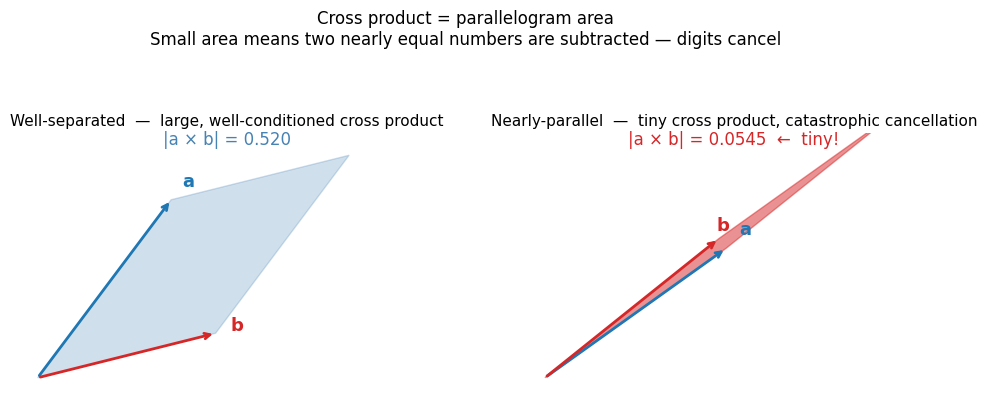

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(top=0.82)  # leave room for suptitle

# --- Left panel: well-separated vectors ---
ax = axes[0]
a1 = np.array([0.6, 0.8])
b1 = np.array([0.8, 0.2])
para1 = plt.Polygon(
    [np.array([0, 0]), a1, a1 + b1, b1], alpha=0.25, color="steelblue", zorder=0
)
ax.add_patch(para1)
ax.annotate(
    "", xy=a1, xytext=[0, 0], arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=2)
)
ax.annotate(
    "", xy=b1, xytext=[0, 0], arrowprops=dict(arrowstyle="->", color="#d62728", lw=2)
)
ax.text(*a1 * 1.08, r"$\mathbf{a}$", fontsize=13, color="#1f77b4")
ax.text(*b1 * 1.08, r"$\mathbf{b}$", fontsize=13, color="#d62728")
area1 = abs(a1[0] * b1[1] - a1[1] * b1[0])
ax.text(
    0.5,
    0.96,
    f"|a × b| = {area1:.3f}",
    ha="center",
    fontsize=12,
    color="steelblue",
    transform=ax.transAxes,
)
ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect("equal")
ax.set_title("Well-separated  —  large, well-conditioned cross product", fontsize=11)
ax.axis("off")

# --- Right panel: nearly-parallel vectors ---
ax = axes[1]
eps = 0.04
a2 = np.array([0.8 + eps, 0.6])
b2 = np.array([0.8, 0.6 + eps])
a2 /= np.linalg.norm(a2)
b2 /= np.linalg.norm(b2)
para2 = plt.Polygon(
    [np.array([0, 0]), a2, a2 + b2, b2], alpha=0.5, color="#d62728", zorder=0
)
ax.add_patch(para2)
ax.annotate(
    "", xy=a2, xytext=[0, 0], arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=2)
)
ax.annotate(
    "", xy=b2, xytext=[0, 0], arrowprops=dict(arrowstyle="->", color="#d62728", lw=2)
)
ax.text(*(a2 * 1.06 + [0.01, 0.03]), r"$\mathbf{a}$", fontsize=13, color="#1f77b4")
ax.text(*(b2 * 1.06 - [0.06, 0.0]), r"$\mathbf{b}$", fontsize=13, color="#d62728")
area2 = abs(a2[0] * b2[1] - a2[1] * b2[0])
ax.text(
    0.5,
    0.96,
    f"|a × b| = {area2:.4f}  ←  tiny!",
    ha="center",
    fontsize=12,
    color="#d62728",
    transform=ax.transAxes,
)
ax.set_xlim(-0.1, 1.8)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect("equal")
ax.set_title(
    "Nearly-parallel  —  tiny cross product, catastrophic cancellation", fontsize=11
)
ax.axis("off")

fig.suptitle(
    "Cross product = parallelogram area\n"
    "Small area means two nearly equal numbers are subtracted — digits cancel",
    fontsize=12,
)
plt.show()

## 2. How UXarray Handles It

UXarray uses **compensated arithmetic** — a family of algorithms that reduce catastrophic cancellation by carrying `(hi, lo)` correction terms through sensitive floating-point operations. There are two distinct layers:

- **Error-free transformations (EFT)** — `two_sum` and `two_prod` are true EFTs: they split a result into a rounded high part and an exact rounding residual so that `hi + lo` equals the true mathematical result with zero information loss.
- **Compensated algorithms** — `diff_of_products` and `accucross` compose EFT primitives to compute cross-product components accurately. They are *not* error-free in the strict sense (the final result still carries one ulp of error), but they achieve roughly double the effective precision compared to naive floating-point evaluation.

The primitives in UXarray are a Python/Numba port of the EFT tier from the [AccuSphGeom](https://github.com/hongyuchen1030/AccuSphGeom) C++ library by Hongyu Chen ([Chen 2026, EGUsphere](https://egusphere.copernicus.org/preprints/2026/egusphere-2026-636/); [SIAM J. Sci. Comput.](https://doi.org/10.1137/25M1737614)). UXarray does not implement AccuSphGeom's full adaptive-predicate or exact-arithmetic fallback stack. The key building blocks live in `uxarray.utils.computing` and `uxarray.grid.arcs`:

| Function | Module | What it does |
|---|---|---|
| `two_sum(a, b)` | `utils.computing` | **EFT**: exact split of `a + b` into `(hi, lo)` |
| `two_prod(a, b)` | `utils.computing` | **EFT**: exact split of `a * b` into `(hi, lo)` |
| `diff_of_products(a, b, c, d)` | `utils.computing` | Compensated `a*b - c*d` |
| `accucross(ax, ay, az, bx, by, bz)` | `utils.computing` | Compensated cross product returning 6 `(hi, lo)` components |
| `orient3d_on_sphere(a, b, q)` | `grid.arcs` | Sign of `(a×b)·q`: +1, −1, or 0 |
| `on_minor_arc(q, a, b)` | `grid.arcs` | True if `q` lies on the minor arc from `a` to `b` |

Most users will never call these directly — they are wired into `Grid.get_point_on_face`, intersection, and zonal operations automatically. But if you are writing custom geometry code that operates on unit vectors, `orient3d_on_sphere` is the right tool for any "which side of a great circle?" question.

In [3]:
from uxarray.grid.arcs import orient3d_on_sphere

# orient3d_on_sphere(A, B, Q) returns the sign of the scalar triple product (A×B)·Q.
#
# Geometrically: A and B define a great circle (the equatorial plane here).
# The sign tells you which hemisphere Q is in relative to that plane:
#
#   +1  Q is on the LEFT  of the directed arc A → B (above the plane by right-hand rule)
#   -1  Q is on the RIGHT of the directed arc A → B (below the plane)
#    0  Q lies exactly on the great circle through A and B
#
# This sign is what every edge-crossing test in point-in-polygon boils down to.

A = np.array([1.0, 0.0, 0.0])  # 0°E on the equator
B = np.array([0.0, 1.0, 0.0])  # 90°E on the equator
# A→B defines the equatorial great circle; right-hand normal points to the North Pole.

north_pole = np.array([0.0, 0.0, 1.0])
south_pole = np.array([0.0, 0.0, -1.0])
on_equator = np.array([0.0, 1.0, 0.0])  # same as B — on the great circle itself


def fmt(v):
    return f"{v:+d}" if v != 0 else " 0"


print(
    f"North Pole:      orient3d = {fmt(orient3d_on_sphere(A, B, north_pole))}  → left  of A→B (northern hemisphere)"
)
print(
    f"South Pole:      orient3d = {fmt(orient3d_on_sphere(A, B, south_pole))}  → right of A→B (southern hemisphere)"
)
print(
    f"On great circle: orient3d = {fmt(orient3d_on_sphere(A, B, on_equator))}  → collinear, not a crossing"
)

North Pole:      orient3d = +1  → left  of A→B (northern hemisphere)
South Pole:      orient3d = -1  → right of A→B (southern hemisphere)
On great circle: orient3d =  0  → collinear, not a crossing


## 3. Seeing It on a Real Mesh: Point-in-Polygon

Point-in-polygon on the sphere works by casting a ray from the query point and counting edge crossings — each crossing test is an `orient3d_on_sphere` sign check. When a query point sits very close to an edge, the cross product of the two edge endpoints is tiny, and its sign is exactly what naive arithmetic gets wrong.

In [4]:
uxds = ux.tutorial.open_dataset("outCSne30-vortex")
grid = uxds.uxgrid
print(f"Grid: {grid.n_face} faces, {grid.n_node} nodes")

Grid: 5400 faces, 5402 nodes


Query points are placed at 50 log-spaced distances from the midpoint of edge V0→V1 on face 0, stepping inward toward the face centroid. The sign of the naive orient3d flips once the distance drops below $\sim \varepsilon_\text{machine} / |V0 \times V1|$.

In [5]:
def normalize(v):
    v = np.asarray(v, dtype=np.float64)
    return v / np.linalg.norm(v)


def lonlat_to_xyz(lon_deg, lat_deg):
    lon, lat = np.radians(lon_deg), np.radians(lat_deg)
    return np.array([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)])


def xyz_to_lonlat(v):
    x, y, z = v
    lat = np.degrees(np.arcsin(np.clip(z, -1, 1)))
    lon = np.degrees(np.arctan2(y, x))
    return lon, lat


fnc = grid.face_node_connectivity.values
n_per = grid.n_nodes_per_face.values
fi = 0
f0 = fnc[fi, : n_per[fi]]
lons = grid.node_lon.values[f0]
lats = grid.node_lat.values[f0]
vertices = np.array([lonlat_to_xyz(lo, la) for lo, la in zip(lons, lats)])

A, B = vertices[0], vertices[1]
cx = A[1] * B[2] - A[2] * B[1]
cy = A[2] * B[0] - A[0] * B[2]
cz = A[0] * B[1] - A[1] * B[0]
cross_mag = np.sqrt(cx**2 + cy**2 + cz**2)
flip_threshold = 2.2e-16 / cross_mag
flip_mm = flip_threshold * 6.371e6 * 1e3  # radians → mm on Earth

# Place 50 query points stepping from the edge midpoint inward toward the centroid.
# All 50 are strictly inside the face — the expected answer for every point is "inside".
edge_mid = normalize(vertices[0] + vertices[1])
centroid_dir = normalize(vertices.sum(axis=0))
epsilons = np.logspace(-3, -16, 50)

_INSIDE = {1, 2, 3}  # _LOC_INSIDE, _LOC_ON_VERTEX, _LOC_ON_EDGE
results, signed_vals = [], []
for eps in epsilons:
    q = normalize(edge_mid + eps * centroid_dir)
    results.append(_point_in_polygon_sphere(q, vertices))
    signed_vals.append(cx * q[0] + cy * q[1] + cz * q[2])

n = len(epsilons)
eft_ok = sum(1 for r in results if r in _INSIDE)
naive_ok = sum(1 for v in signed_vals if v > 0)

print(f"Face 0 edge V0→V1:  |V0 × V1| = {cross_mag:.5f}")
print(
    f"Naive sign flips below ε ≈ {flip_threshold:.1e} rad  ({flip_mm:.2e} mm on Earth)"
)
print()
print(f"All {n} query points are inside face 0 — correct answer is always 'inside'.")
print(f"  EFT   (orient3d_on_sphere): {eft_ok}/{n} correctly classified as inside")
print(
    f"  Naive (raw cross product):  {naive_ok}/{n} correctly classified as inside"
    f"  ← {n - naive_ok} misclassified as outside near the edge"
)

Face 0 edge V0→V1:  |V0 × V1| = 0.04851
Naive sign flips below ε ≈ 4.5e-15 rad  (2.89e-05 mm on Earth)

All 50 query points are inside face 0 — correct answer is always 'inside'.
  EFT   (orient3d_on_sphere): 50/50 correctly classified as inside
  Naive (raw cross product):  42/50 correctly classified as inside  ← 8 misclassified as outside near the edge


When the query is close enough to the edge, the naive orient3d value rounds to the wrong sign — the crossing test flips and the point is misclassified as outside. A misclassified point on a shared edge is either silently dropped or double-counted in the output. Compensated arithmetic keeps the correct sign down to machine precision.

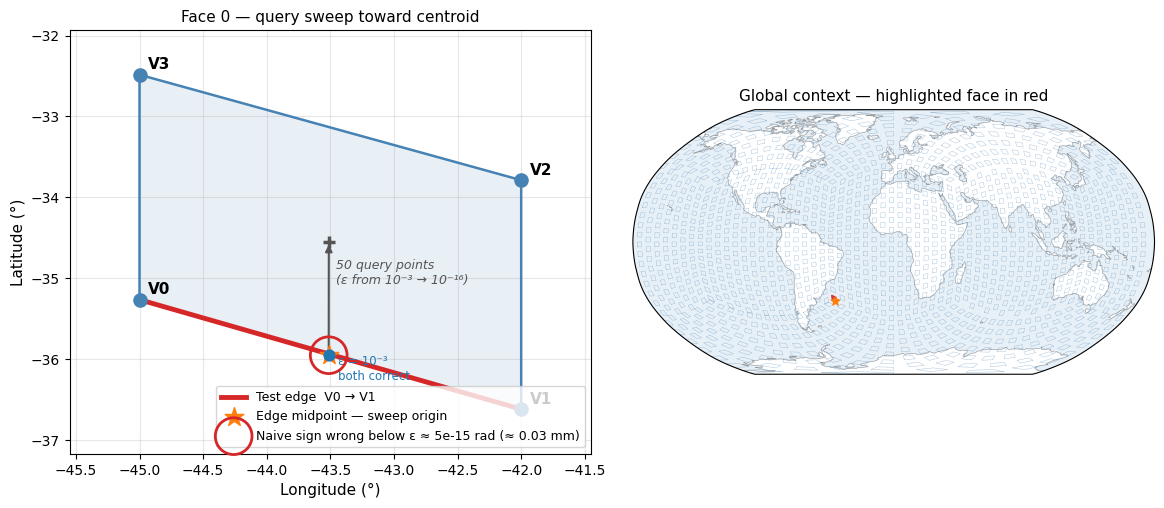

In [6]:
node_lon = grid.node_lon.values
node_lat = grid.node_lat.values

fig = plt.figure(figsize=(14, 5.5))
fig.subplots_adjust(wspace=0.08)

# ── Left: zoomed face ──────────────────────────────────────────────────────
ax = fig.add_subplot(1, 2, 1)

face_lons = np.append(lons, lons[0])
face_lats = np.append(lats, lats[0])
ax.fill(face_lons, face_lats, alpha=0.12, color="steelblue", zorder=1)
ax.plot(face_lons, face_lats, "-", color="steelblue", linewidth=1.8, zorder=2)
ax.plot(
    [lons[0], lons[1]],
    [lats[0], lats[1]],
    "-",
    color="#d62728",
    linewidth=3.5,
    zorder=3,
    label="Test edge  V0 → V1",
)

for i, (lo, la) in enumerate(zip(lons, lats)):
    ax.scatter(lo, la, s=90, color="steelblue", zorder=5, clip_on=False)
    ax.annotate(
        f"V{i}",
        (lo, la),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=11,
        fontweight="bold",
    )

cen_lon, cen_lat = xyz_to_lonlat(normalize(vertices.sum(axis=0)))
ax.scatter(cen_lon, cen_lat, s=70, color="#555", marker="+", linewidths=2.5, zorder=5)

em_lon, em_lat = xyz_to_lonlat(normalize(vertices[0] + vertices[1]))
ax.scatter(
    em_lon,
    em_lat,
    s=200,
    color="#ff7f0e",
    marker="*",
    zorder=6,
    label="Edge midpoint — sweep origin",
)

ax.annotate(
    "",
    xy=(cen_lon, cen_lat),
    xytext=(em_lon, em_lat),
    arrowprops=dict(arrowstyle="-|>", color="#555", lw=1.5),
)
ax.text(
    (em_lon + cen_lon) / 2 + 0.06,
    (em_lat + cen_lat) / 2 + 0.18,
    "50 query points\n(ε from 10⁻³ → 10⁻¹⁶)",
    fontsize=9,
    color="#555",
    style="italic",
)

ax.scatter(
    em_lon,
    em_lat,
    s=700,
    facecolors="none",
    edgecolors="#d62728",
    linewidths=2,
    zorder=7,
    label=f"Naive sign wrong below ε ≈ {flip_threshold:.0e} rad (≈ 0.03 mm)",
)

q_far = normalize(
    normalize(vertices[0] + vertices[1]) + 1e-3 * normalize(vertices.sum(axis=0))
)
qf_lon, qf_lat = xyz_to_lonlat(q_far)
ax.scatter(qf_lon, qf_lat, s=60, color="#1f77b4", zorder=6)
ax.annotate(
    "ε = 10⁻³\nboth correct",
    (qf_lon, qf_lat),
    textcoords="offset points",
    xytext=(7, -18),
    fontsize=8.5,
    color="#1f77b4",
)

ax.set_xlabel("Longitude (°)", fontsize=11)
ax.set_ylabel("Latitude (°)", fontsize=11)
ax.set_title("Face 0 — query sweep toward centroid", fontsize=11)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
pad = 0.55
ax.set_xlim(lons.min() - pad, lons.max() + pad)
ax.set_ylim(lats.min() - pad, lats.max() + pad)

# ── Right: global context ──────────────────────────────────────────────────
ax_global = fig.add_subplot(1, 2, 2, projection=ccrs.Robinson())
ax_global.set_global()
ax_global.add_feature(cfeature.OCEAN, color="#e8f0f7", zorder=0)
ax_global.add_feature(cfeature.COASTLINE, linewidth=0.4, color="#999", zorder=1)
for fi_g in range(0, grid.n_face, 4):
    verts_g = fnc[fi_g, : n_per[fi_g]]
    lf = node_lon[verts_g]
    la_ = node_lat[verts_g]
    if lf.max() - lf.min() > 180:
        continue
    ax_global.plot(
        np.append(lf, lf[0]),
        np.append(la_, la_[0]),
        "-",
        color="steelblue",
        linewidth=0.3,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=2,
    )
ax_global.fill(
    face_lons,
    face_lats,
    alpha=0.8,
    color="#d62728",
    zorder=4,
    transform=ccrs.PlateCarree(),
)
ax_global.scatter(
    em_lon,
    em_lat,
    s=40,
    color="#ff7f0e",
    marker="*",
    zorder=5,
    transform=ccrs.PlateCarree(),
)
ax_global.set_title("Global context — highlighted face in red", fontsize=11)

plt.show()

## 4. Where It Is Used in UXarray

Compensated arithmetic is wired into every module that performs geometric predicates on the sphere. The table below maps each user-facing operation to the underlying accurate function that protects it.

| User-facing operation | Module | Accurate function(s) used |
|---|---|---|
| `Grid.get_point_on_face()` | `grid/point_in_face.py` | `orient3d_on_sphere`, `on_minor_arc` |
| Arc–arc intersection (remapping, antimeridian) | `grid/intersections.py` | `accucross`, `accucross_pair`, `on_minor_arc` |
| Arc–latitude intersection (zonal averages) | `grid/intersections.py` | `accucross`, `acc_sqrt_re`, `on_minor_arc` |
| Face lat/lon bounds (bounding-box queries) | `grid/bounds.py` | `orient3d_on_sphere` (pole check) |
| Antimeridian detection & splitting | `grid/geometry.py` | `orient3d_on_sphere`, `on_minor_arc` |
| Zonal means (`Grid.zonal_mean`) | `core/zonal.py` | via `gca_const_lat_intersection` |
| Face area integration | `grid/integrate.py` | via `gca_const_lat_intersection` |

If you extend UXarray with custom geometry — for example, a new remapping kernel or a spatial predicate — use `orient3d_on_sphere` from `uxarray.grid.arcs` for any signed orientation test, and `on_minor_arc` for arc-membership tests. Both are Numba-compiled and drop-in replacements for the equivalent naive cross-product code.